<a href="https://colab.research.google.com/github/Nam19ti/ML/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1368,ham,Alright. I'm out--have a good night!,NaN,NaN,NaN
5037,ham,Thanks for being there for me just to talk to ...,NaN,NaN,NaN
3016,ham,One of the joys in lifeis waking up each daywi...,NaN,NaN,NaN
2628,ham,Haha... They cant what... At the most tmr forf...,NaN,NaN,NaN
3090,spam,LORD OF THE RINGS:RETURN OF THE KING in store ...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## Tiền xử lý dữ liệu (Data Preprocessing)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


- **Cột thừa**: các cột `Unnamed` không có giá trị phân tích.


In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.sample(5)

,v1,v2
1899,ham,I love working from home :)
766,ham,"I'm nt goin, got somethin on, unless they meet..."
3102,ham,"U so lousy, run already come back then half de..."
3734,ham,"ItÛ÷s å£6 to get in, is that ok?"
5559,ham,if you aren't here in the next &lt;#&gt; hou...


- **Tên cột không rõ ràng**: `v1`, `v2` → cần đổi thành `target`, `text` để dễ đọc.

In [8]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1392,ham,"Thk shld b can... Ya, i wana go 4 lessons... H..."
4807,ham,What's up my own oga. Left my phone at home an...
4472,ham,S but not able to sleep.
1327,spam,Ur balance is now å£500. Ur next question is: ...
1584,ham,"Sorry, I'll call later"


###  Label Encoding — Mã hóa nhãn

`LabelEncoder` chuyển nhãn dạng chuỗi thành số nguyên:

$$\text{ham} \rightarrow 0, \quad \text{spam} \rightarrow 1$$



In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


- **Kiểm tra giá trị NaN**

In [12]:

df.isnull().sum()

,0
target,0
text,0


**Kiểm tra bản ghi trùng lặp**

In [13]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [14]:

df = df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

Xóa bản ghi trùng lặp giúp tránh data leakage — mô hình nhớ dữ liệu test nếu cùng một mẫu xuất hiện ở cả train và test set.

In [16]:
df.shape

(5169, 2)

## Khám phá dữ liệu (EDA)

In [17]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df['target'].value_counts()

,count
target,
0,4516
1,653


#Tỷ lệ giữa tin nhắn thường (ham) và tin nhắn rác (spam)

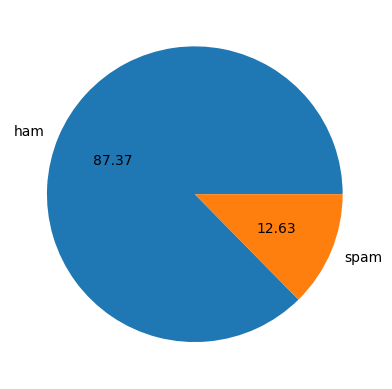

In [19]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

Dữ liệu bị mất cân bằng (imbalanced data): khoảng 87.37% là tin thường và 12.63% là spam

Mô hình có xu hướng dự đoán ham cho mọi mẫu để đạt accuracy ~87%

 Cần dùng Precision, Recall, Fβ thay vì chỉ dùng Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> Trong bài toán spam, ta ưu tiên Precision cao để tránh đánh nhầm ham thành spam (False Positive).


In [20]:
import nltk  # Thư viện xử lý ngôn ngữ tự nhiên
nltk.download('punkt') # Tải bộ tách từ và câu
nltk.download('punkt_tab') # Tải dữ liệu bổ sung cho punkt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['num_characters'] = df['text'].apply(len)
#Tạo cột mới num_characters chứa số ký tự của mỗi tin nhắn/email trong cột text.

In [22]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
# Tạo cột num_words chứa số từ trong mỗi tin nhắn/email.

In [24]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
# Tạo cột num_sentences chứa số câu trong mỗi tin nhắn/email.

In [26]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Một tin nhắn spam có thể chứa số lượng ký tự, số từ và số câu trung bình cao hơn nhiều so với tin nhắn thông thường

In [30]:
import seaborn as sns

#Biểu đồ phân phối của độ dài ký tự giữa hai nhóm ham và spam

<Axes: xlabel='num_characters', ylabel='Count'>

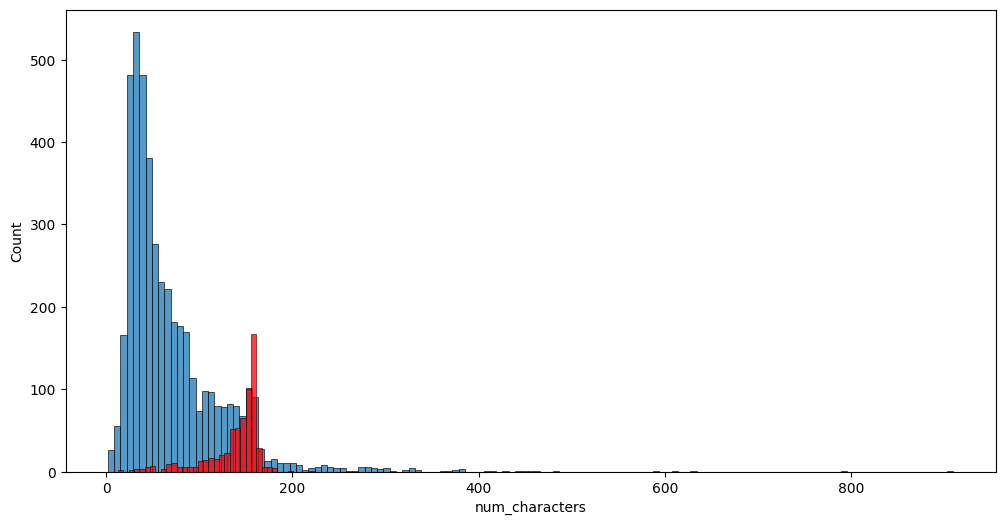

In [31]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

### 🔍 Phân tích biểu đồ phân phối `num_characters`

Biểu đồ histogram trên (màu **xanh = ham**, màu **đỏ = spam**) cho thấy:

- **Ham** có phân phối **lệch phải mạnh** — đỉnh tập trung ở 0–80 ký tự, rất ít tin dài hơn 150 ký tự.
- **Spam** có phân phối **rải rộng hơn nhiều** — phần lớn nằm trong khoảng 100–200 ký tự.

➡️ **`num_characters` là đặc trưng phân tách ranh giới ham/spam rõ ràng nhất** trong số 3 đặc trưng tạo ra.

Ranh giới phân tách (threshold) sơ bộ có thể đặt ở khoảng **~100 ký tự**:
- Tin nhắn có ít hơn 100 ký tự → rất có khả năng là **ham**
- Tin nhắn dài hơn 100 ký tự → nghi ngờ là **spam** (xác suất cao hơn đáng kể)

> ⚙️ Đây chính là lý do mà trong Heatmap tương quan, `num_characters` có hệ số tương quan **0.38** với `target` — cao nhất trong 3 đặc trưng số.


<Axes: xlabel='num_words', ylabel='Count'>

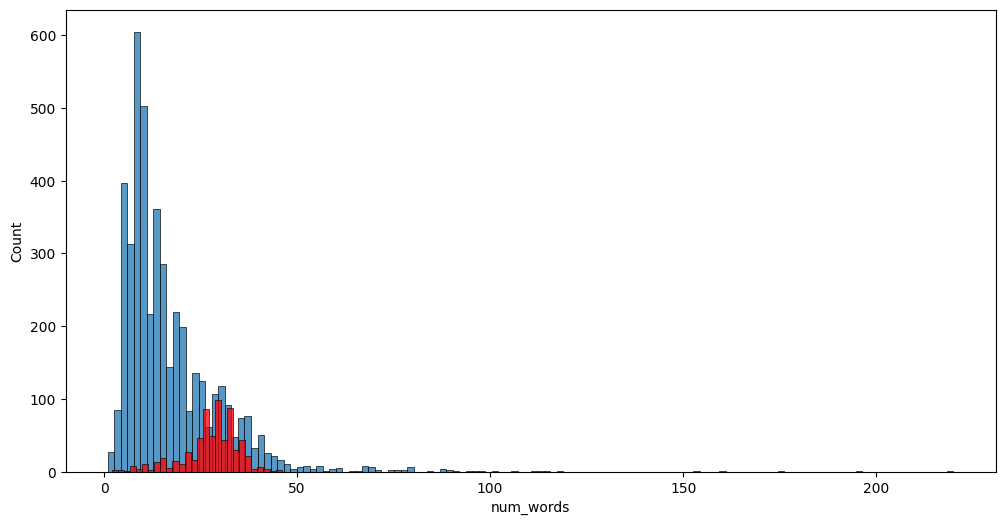

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

### 🔍 Phân tích biểu đồ phân phối `num_words`

- **Ham**: phần lớn dưới **20 từ** — tin nhắn ngắn gọn, đời thường.
- **Spam**: phân phối rộng hơn, trung bình **~28 từ**, nhiều tin nhắn lên đến 50–70 từ.

Mặc dù `num_words` cũng cho thấy sự khác biệt giữa 2 nhóm, nhưng **mức độ chồng lấp giữa hai phân phối lớn hơn** so với `num_characters`.

> 📌 **Kết luận từ cả 2 biểu đồ**:  
> Thứ tự phân tách ranh giới từ tốt nhất → kém nhất:  
> **`num_characters`** > **`num_words`** > **`num_sentences`**


 # Mối quan hệ giữa các biến

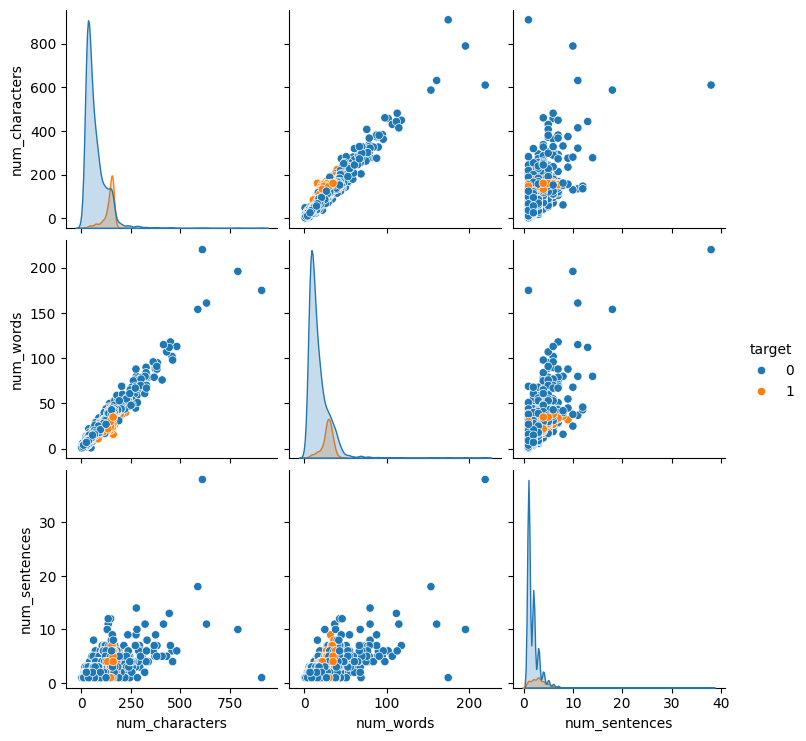

In [33]:
sns.pairplot(df,hue='target')

<Axes: >

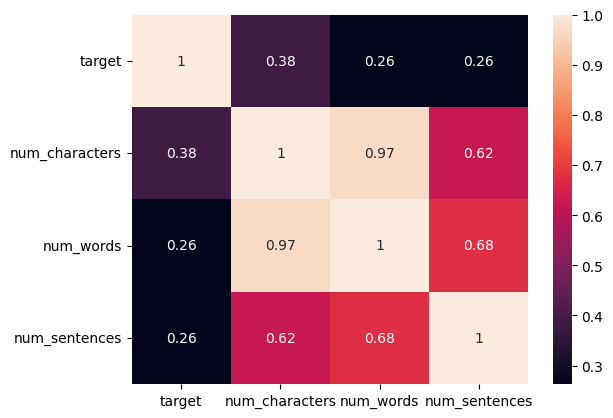

In [34]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

- 3 đặc trưng mới (num_characters, num_words, num_sentences) đều có tương quan dương với biến target (1 là spam) -> các chỉ số này tăng lên, khả năng tin nhắn đó là spam cũng tăng theo
- num_characters và num_words có hệ số tương quan lên tới 0.97 -> chứa nhiều thông tin tương đồng nhau.
- chọn cột num_characters làm đại diện chính vì nó có hệ số tương quan tốt nhất với biến mục tiêu (0.38) so với các cột còn lại

Kiểm định Đa cộng tuyến bằng Hệ số VIF (Variance Inflation Factor)

## Kiểm định Đa cộng tuyến bằng Hệ số VIF (Variance Inflation Factor)


**VIF** đo lường mức độ một biến độc lập có thể được giải thích bởi các biến độc lập còn lại:

  `VIF = 1 / (1 - R^2)`

- **VIF = 1:** Không có đa cộng tuyến.
- **1 < VIF < 5:** Đa cộng tuyến ở mức chấp nhận được.
- **VIF > 10:** Đa cộng tuyến nghiêm trọng — cần xem xét loại bỏ biến.

Hệ số VIF bổ sung cho ma trận tương quan vì nó đo lường ảnh hưởng **tổng hợp** của tất cả các biến khác, không chỉ từng cặp.

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def get_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

In [36]:
get_vif(df[[i for i in df.describe().columns if i != 'target']])


,variables,VIF
0,num_characters,43.072540
1,num_words,50.692198
2,num_sentences,4.870652


In [37]:
df.drop(columns=['num_characters'], inplace=True)
df.head()

,target,text,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",24,2
1,0,Ok lar... Joking wif u oni...,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2
3,0,U dun say so early hor... U c already then say...,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1


In [38]:
import string
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem.porter import PorterStemmer
def transform_text(text):
    text = text.lower() #Chuyển về chữ thường
    text = nltk.word_tokenize(text) #Tách từ

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ dấu câu và ký tự đặc biệt, chỉ giữ chữ và số
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
#loại bỏ các từ ít ý nghĩa như: a, an, the, is, of,...
    for i in text:
        y.append(ps.stem(i))
#đưa từ về dạng nguyên thể

    return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
ps = PorterStemmer()
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [40]:
df['transformed_text'] = df['text'].apply(transform_text)

In [41]:
df.head()

,target,text,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,nah think goe usf live around though


In [42]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [43]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Spam

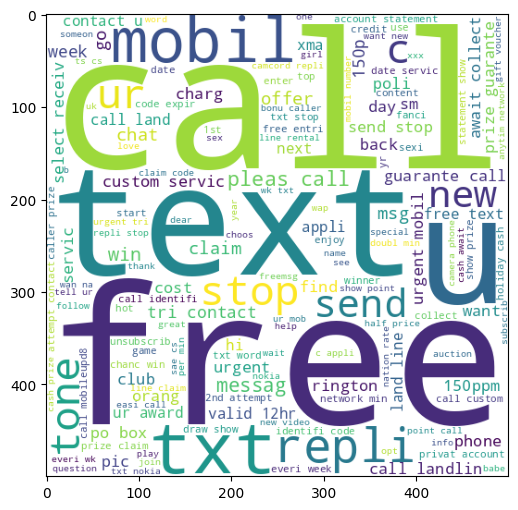

In [44]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

Tin nhắn spam thường chứa các từ khóa đặc trưng nhằm mục đích lôi kéo người dùng như: "call", "free", "offer", "prize", "text", "urgent"

In [45]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

# Tần suất xuất hiện từ trong tin nhắn Ham

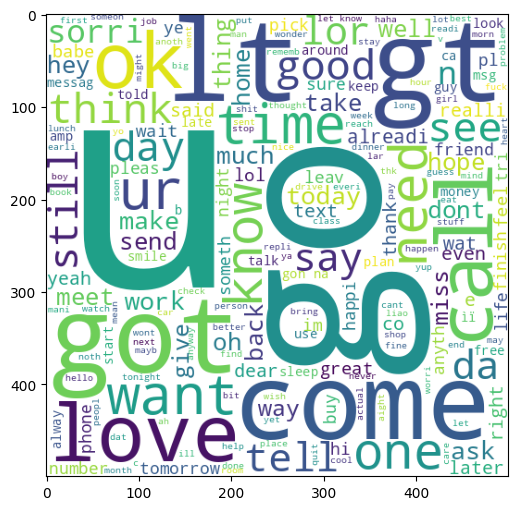

In [46]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

Tin nhắn thường, các từ xuất hiện phổ biến hơn mang tính giao tiếp đời thường như: "go", "come", "got", "love",...

In [47]:
df.head()

,target,text,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,nah think goe usf live around though


In [48]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn spam
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [49]:
len(spam_corpus)

9939

# Các từ xuất hiện nhiều nhất trong tin nhắn spam

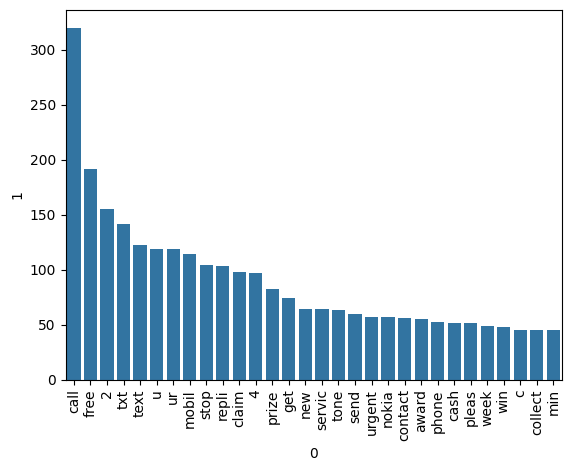

In [50]:
from collections import Counter

df_temp = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(
    x=df_temp[0],
    y=df_temp[1]
)

plt.xticks(rotation='vertical')
plt.show()

In [51]:
# Tạo danh sách chứa tất cả từ trong các tin nhắn ham
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [52]:
len(ham_corpus)

35404

# Các từ xuất hiện nhiều nhất trong tin nhắn ham

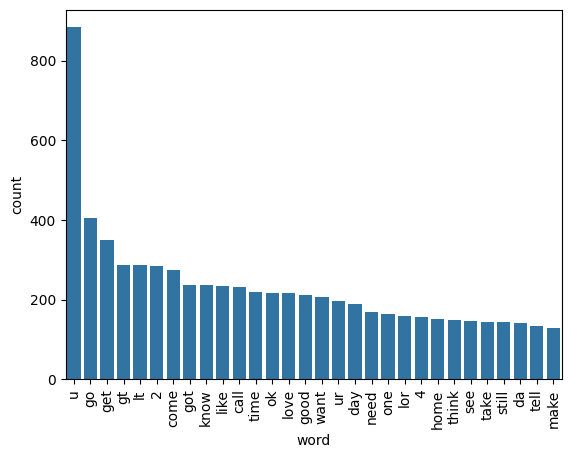

In [53]:
from collections import Counter

ham_df = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(
    data=ham_df,
    x='word',
    y='count'
)

plt.xticks(rotation=90)
plt.show()

In [54]:

df.head()

,target,text,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,nah think goe usf live around though


## 4. Model Building

### Biểu diễn văn bản dạng số — Text Vectorization

Mô hình ML không đọc được văn bản — cần chuyển thành **vector số**. Có hai phương pháp phổ biến:

#### 1. Bag of Words (BoW) — `CountVectorizer`
Mỗi văn bản được biểu diễn bằng **vector đếm số lần xuất hiện** của từng từ trong từ điển:

$$\text{BoW}(d) = [c_1, c_2, ..., c_V]$$

Trong đó $c_i$ là số lần từ $w_i$ xuất hiện trong văn bản $d$, $V$ là kích thước từ điển.

**Hạn chế**: Từ xuất hiện nhiều như "the", "is" sẽ có trọng số cao dù không mang nghĩa → TF-IDF giải quyết điều này.

#### 2. TF-IDF — `TfidfVectorizer`

$$\text{TF}(t, d) = \frac{\text{số lần } t \text{ xuất hiện trong } d}{\text{tổng số từ trong } d}$$

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Trong đó:
- $N$: tổng số văn bản trong corpus
- $\text{df}(t)$: số văn bản chứa từ $t$

TF-IDF không chỉ đếm số lần xuất hiện của từ mà còn đánh giá mức độ quan trọng của từ trong toàn bộ tập dữ liệu. Điều này giúp mô hình tập trung vào các từ đặc trưng của email spam và thường cho kết quả tốt hơn Bag of Words.

In [55]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
y = df['target'].values

In [58]:
X_train, X_test, y_train, y_test = train_test_split(df['transformed_text'], y, test_size=0.2, random_state=2)
X_train = tfidf.fit_transform(X_train).toarray()
X_test = tfidf.transform(X_test).toarray()

### 1. Mô hình cơ sở (Baseline Model): Multinomial Naive Bayes (MNB)

**Lý do lựa chọn:**: Multinomial Naive Bayes là thuật toán phân loại văn bản phổ biến, hoạt động dựa trên định lý Bayes và giả định các đặc trưng độc lập có điều kiện. Khi kết hợp với biểu diễn văn bản bằng TF-IDF, mô hình có tốc độ huấn luyện nhanh, dễ triển khai và thường đạt hiệu quả cao trong các bài toán lọc thư rác.

### 2. Mô hình nâng cao: XGBoost Classifier (Extreme Gradient Boosting)

**Lý do lựa chọn:**: XGBoost là thuật toán học tăng cường (Boosting) sử dụng tập hợp nhiều cây quyết định để cải thiện khả năng dự đoán. Không giống Naive Bayes, XGBoost có thể học được các mối quan hệ phi tuyến và tương tác phức tạp giữa các đặc trưng. Ngoài ra, thuật toán còn tích hợp các cơ chế regularization giúp giảm hiện tượng overfitting và nâng cao hiệu năng trên nhiều bộ dữ liệu thực tế.

## 1. Khởi tạo dự đoán ban đầu
Mô hình bắt đầu với một giá trị dự đoán ban đầu cho toàn bộ tập dữ liệu. Đối với bài toán phân loại nhị phân, giá trị này thường được biểu diễn dưới dạng xác suất thuộc lớp dương (spam).

Sau đó, sai số dự đoán của từng mẫu được sử dụng để xây dựng cây quyết định tiếp theo.

## 2. Đánh giá mức độ cải thiện tại mỗi nút
Tại mỗi nút của cây, XGBoost sử dụng thông tin về sai số dự đoán để đánh giá mức độ đồng nhất của các mẫu dữ liệu.

Mục tiêu là tìm ra cách phân chia dữ liệu giúp giảm hàm mất mát nhiều nhất và cải thiện khả năng phân loại của mô hình.

## 3. Tìm điểm phân chia tối ưu
Thuật toán lần lượt thử các điểm chia trên từng thuộc tính.

Đối với mỗi phép chia, dữ liệu được tách thành nút trái và nút phải. Sau đó, XGBoost tính giá trị Gain để đo lường mức độ cải thiện sau khi phân chia.

$$Gain = \frac{1}{2} \left( \frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda} \right) -\gamma$$

Trong đó:
- $G$: tổng Gradient.
- $H$: tổng Hessian.
- $\lambda$: hệ số điều chuẩn.
- $\gamma$: ngưỡng cắt tỉa cây.

Điểm chia có giá trị Gain lớn nhất sẽ được lựa chọn.

## 4. Cắt tỉa cây (Pruning)
Sau khi tính Gain, XGBoost sử dụng tham số $\gamma$ để kiểm soát độ phức tạp của cây.

Nếu giá trị Gain không đủ lớn để cải thiện mô hình, phép chia sẽ bị loại bỏ nhằm hạn chế hiện tượng overfitting.

## 5. Tính giá trị đầu ra tại lá
Khi không thể tiếp tục phân chia, nút sẽ trở thành lá.

Giá trị đầu ra của mỗi lá được tính dựa trên tổng Gradient và Hessian của các mẫu dữ liệu thuộc lá đó:

$$w = -\frac{G}{H+\lambda}$$

Giá trị này thể hiện mức điều chỉnh dự đoán mà lá đóng góp cho mô hình.

## 6. Cập nhật dự đoán
Sau khi cây được xây dựng hoàn chỉnh, dự đoán được cập nhật theo công thức:

$$\hat{y}_{new} = \hat{y}_{old} + \eta \times w$$

Trong đó:
- $\eta$: Learning Rate.
- $w$: giá trị đầu ra của lá.

In [59]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,fbeta_score, recall_score

* Gaussian Naive Bayes: dùng cho các đặc trưng là biến liên tục (ví dụ: chiều cao, cân nặng, giá trị pixel)
*  Multinomial Naive Bayes: dùng cho các đặc trưng là biến đếm (count)
* Bernoulli Naive Bayes: dùng cho các đặc trưng là biến nhị phân (0 hoặc 1)
# -> Multinomial Naive Bayes phù hợp cho bài toán phân loại văn bản

In [60]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

Dữ liệu bị mất cân bằng (imbalanced data), nên Accuracy (độ chính xác) không phải là thước đo đáng tin cậy nhất.
Tập trung vào chỉ số Precision (Độ chính xác của việc dự báo spam)
- Mục tiêu là tối đa hóa Precision để tránh việc tin nhắn bình thường (ham) bị hệ thống nhầm lẫn đánh dấu là spam (giảm thiểu False Positives).

In [61]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(recall_score(y_test,y_pred2))
print(fbeta_score(y_test, y_pred2, beta=0.5))

0.9671179883945842
[[896   0]
 [ 34 104]]
1.0
0.7536231884057971
0.9386281588447654


In [62]:
y_train_pred_before_tuning = mnb.predict(X_train)
print("Dự đoán trên tập huấn luyện (y_train_pred) trước khi tinh chỉnh:")
print(y_train_pred_before_tuning)

Dự đoán trên tập huấn luyện (y_train_pred) trước khi tinh chỉnh:
[0 0 0 ... 0 0 0]


In [63]:
def train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f0_5_score = fbeta_score(y_test, y_pred, beta=0.5)

    return accuracy, precision, recall, f0_5_score

In [64]:
# tfidf --> MNB

In [65]:
from sklearn.metrics import fbeta_score, recall_score

def train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f0_5_score = fbeta_score(y_test, y_pred, beta=0.5)

    return accuracy, precision, recall, f0_5_score

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

mnb = MultinomialNB()
xgb = XGBClassifier(random_state=42)

clfs = {
    'NB': mnb,
    'xgb':xgb
}

accuracy_scores = []
precision_scores = []
recall_scores = []
f0_5_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f0_5_score = train_classifier_with_fbeta(clf, X_train, y_train, X_test, y_test)

    print(f"For {name}")
    print(f"Accuracy - {current_accuracy}")
    print(f"Precision - {current_precision}")
    print(f"Recall - {current_recall}")
    print(f"F0.5-Score - {current_f0_5_score}")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f0_5_scores.append(current_f0_5_score)

For NB
Accuracy - 0.9671179883945842
Precision - 1.0
Recall - 0.7536231884057971
F0.5-Score - 0.9386281588447654
For xgb
Accuracy - 0.9729206963249516
Precision - 0.9435483870967742
Recall - 0.8478260869565217
F0.5-Score - 0.9227129337539433


In [67]:

performance_df_fbeta = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F0.5_Score': f0_5_scores
}).sort_values('F0.5_Score', ascending=False)

display(performance_df_fbeta)

,Algorithm,Accuracy,Precision,Recall,F0.5_Score
0,NB,0.967118,1.000000,0.753623,0.938628
1,xgb,0.972921,0.943548,0.847826,0.922713


## Evaluation metrics
## Precision
Precision đo tỷ lệ email được dự đoán là spam thực sự là spam:

$$Precision = \frac{TP}{TP + FP}$$

## Recall
Recall đo khả năng phát hiện các email spam thực tế:

$$Recall = \frac{TP}{TP + FN}$$

## Accuracy
Accuracy đo tỷ lệ dự đoán đúng trên toàn bộ tập dữ liệu:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

## F$\beta$-Score

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$



Dữ liệu bị mất cân bằng (imbalanced data), nên Accuracy (độ chính xác) không phải là thước đo đáng tin cậy nhất.
Tập trung vào chỉ số Precision (Độ chính xác của việc dự báo spam)
- Mục tiêu là tối đa hóa Precision để tránh việc tin nhắn bình thường (ham) bị hệ thống nhầm lẫn đánh dấu là spam (giảm thiểu False Positives).

**Trong bài này**, ta dùng **F0.5-Score** ($\beta = 0.5$) vì chi phí của **False Positive** (ham bị đánh dấu spam khiến người dùng mất tin nhắn quan trọng) cao hơn **False Negative** (một vài spam lọt qua).


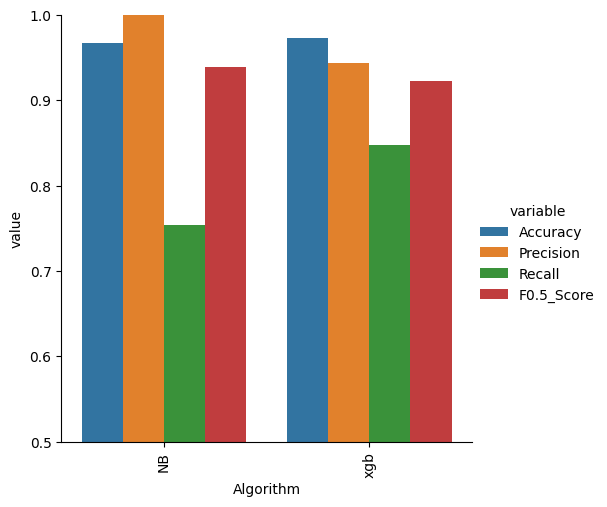

In [70]:
melted_performance_df = performance_df_fbeta.melt(id_vars='Algorithm', var_name='variable', value_name='value')
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=melted_performance_df, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

### Áp dụng RandomizedSearchCV để tinh chỉnh siêu tham số cho XGBoost

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, classification_report
import scipy.stats as stats

f05_scorer = make_scorer(fbeta_score, beta=0.5)
# Define the parameter distributions for XGBoost
param_dist_xgb = {
 # 1. Cấu trúc và tốc độ học
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 6, 10, 15, 20],

    # 2. Lấy mẫu ngẫu nhiên (Tránh trùng lặp)
    'subsample': np.arange(0.5, 1.0, 0.1),
    'colsample_bytree':  np.arange(0.4, 1.0, 0.1),

    # 3. Phạt Regularization (Chống overfitting)
    'gamma': [0, 0.1, 0.2, 0.5, 1],
    'reg_lambda':[0.1, 1, 5, 10, 50, 100],
    'reg_alpha': [0, 0.1, 1, 5]
}

# Create a RandomizedSearchCV object for XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    scoring=f05_scorer,
    n_iter=25, # Number of parameter settings that are sampled
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the randomized search to the training data
random_search_xgb.fit(X_train, y_train)

print("\n=== KẾT QUẢ TÌM KIẾM CHO XGBoost ===")
print("Bộ tham số tối ưu nhất:", random_search_xgb.best_params_)
print(f"Điểm F0.5 tốt nhất đạt được trên tập train: {random_search_xgb.best_score_:.4f}")

best_model_xgb = random_search_xgb.best_estimator_
y_pred_random_xgb = best_model_xgb.predict(X_test)

print("\n=== BẢNG ĐÁNH GIÁ TRÊN TẬP TEST SAU KHI TINH CHỈNH (XGBoost) ===")
print(classification_report(y_test, y_pred_random_xgb, digits=4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:40:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== KẾT QUẢ TÌM KIẾM CHO XGBoost ===
Bộ tham số tối ưu nhất: {'subsample': np.float64(0.7999999999999999), 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': np.float64(0.6)}
Điểm F0.5 tốt nhất đạt được trên tập train: 0.8985

=== BẢNG ĐÁNH GIÁ TRÊN TẬP TEST SAU KHI TINH CHỈNH (XGBoost) ===
              precision    recall  f1-score   support

           0     0.9664    0.9955    0.9808       896
           1     0.9640    0.7754    0.8594       138

    accuracy                         0.9662      1034
   macro avg     0.9652    0.8854    0.9201      1034
weighted avg     0.9661    0.9662    0.9646      1034

